EXPERIMENT 08 - TASK 03
ANN Hyperparameter Optimization
Name    : R. Karthik
Roll No : 25EU02904

Optimizer Comparison:
adam: 78.86% validation accuracy
sgd: 78.05% validation accuracy
rmsprop: 81.30% validation accuracy

Best Optimizer: rmsprop

Tuned Model Test Accuracy: 72.08%
Training Epochs Completed: 33


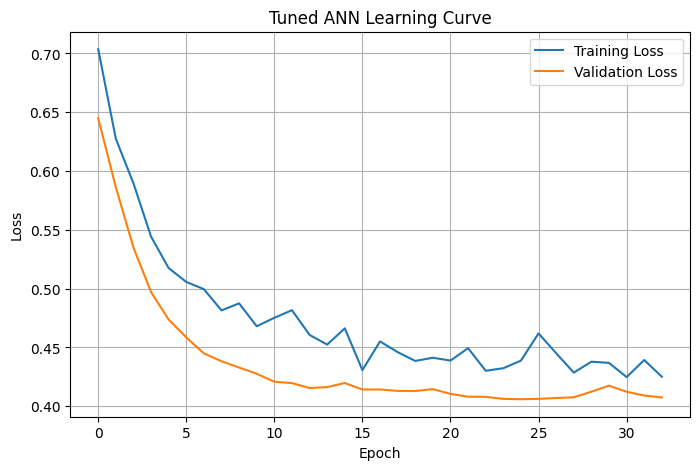


TASK 03 COMPLETED SUCCESSFULLY
Hyperparameter tuning and Early Stopping were applied.
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 08 - TASK 03
# ANN Hyperparameter Optimization
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("=" * 60)
print("EXPERIMENT 08 - TASK 03")
print("ANN Hyperparameter Optimization")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Pima Dataset
# ------------------------------------------------------------

url = (
    "https://raw.githubusercontent.com/"
    "jbrownlee/Datasets/master/"
    "pima-indians-diabetes.data.csv"
)

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]

# ------------------------------------------------------------
# 2. Handle Invalid Values
# ------------------------------------------------------------

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = (
    X[invalid_columns]
    .replace(0, np.nan)
)

X = X.fillna(
    X.median()
)

# ------------------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# 4. Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# ------------------------------------------------------------
# 5. ANN Builder Function
# ------------------------------------------------------------

def build_model(
    optimizer="adam",
    hidden_units=16,
    dropout_rate=0.0
):

    model = Sequential([
        Dense(
            hidden_units,
            activation="relu",
            input_shape=(X_train.shape[1],)
        ),

        Dropout(
            dropout_rate
        ),

        Dense(
            8,
            activation="relu"
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ------------------------------------------------------------
# 6. Compare Optimizers
# ------------------------------------------------------------

optimizers = [
    "adam",
    "sgd",
    "rmsprop"
]

optimizer_results = {}

for optimizer in optimizers:

    model = build_model(
        optimizer=optimizer,
        hidden_units=16,
        dropout_rate=0.2
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=40,
        batch_size=16,
        verbose=0
    )

    optimizer_results[optimizer] = (
        history.history["val_accuracy"][-1]
    )

print("\nOptimizer Comparison:")

for optimizer, score in optimizer_results.items():

    print(
        f"{optimizer}: "
        f"{score * 100:.2f}% validation accuracy"
    )

# ------------------------------------------------------------
# 7. Select Best Optimizer
# ------------------------------------------------------------

best_optimizer = max(
    optimizer_results,
    key=optimizer_results.get
)

print(
    f"\nBest Optimizer: "
    f"{best_optimizer}"
)

# ------------------------------------------------------------
# 8. Train Tuned Model with Early Stopping
# ------------------------------------------------------------

tuned_model = build_model(
    optimizer=best_optimizer,
    hidden_units=32,
    dropout_rate=0.2
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = tuned_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0
)

# ------------------------------------------------------------
# 9. Evaluate Tuned Model
# ------------------------------------------------------------

probabilities = tuned_model.predict(
    X_test,
    verbose=0
).ravel()

predictions = (
    probabilities >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"\nTuned Model Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Training Epochs Completed: "
    f"{len(history.history['loss'])}"
)

# ------------------------------------------------------------
# 10. Learning Curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Tuned ANN Learning Curve"
)

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 03 COMPLETED SUCCESSFULLY")
print("Hyperparameter tuning and Early Stopping were applied.")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)